<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Modeling/Blood%20pressure%20and%20age/blood-pressure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Pressure

Does blood pressure increase with age?

The `blood-pressure-usa.csv` file contains systolic blood pressure readings from 100 individuals sampled by the National Health and Nutrition Examination Survey (NHANES) in the U.S., with each person measured three times.

The `blood-pressure-yanomami.csv` file features systolic blood pressure data from 71 individuals of the Yanomami Tribe, who live in near-total isolation in the Amazon.

While the average American consumes about 3,500 mg of sodium daily (from salt), the Yanomami's intake is estimated to be less than 100 mg.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'blood-pressure-usa.csv', 'blood-pressure-yanomami.csv', and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving blood-pressure-usa.csv to blood-pressure-usa.csv
Saving blood-pressure-yanomami.csv to blood-pressure-yanomami.csv
Saving linear_model.py to linear_model.py


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('blood-pressure-usa.csv')
df.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [4]:
df_remote = pd.read_csv('blood-pressure-yanomami.csv')
df_remote.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107


### Project Ideas

- Calculate the average blood pressure for each participant in the US dataset.

- Create a linear model for both the US and Yanomami datasets that predicts `bp` from `age`	.

- Compare the best-fit lines and goodness of fit. What conclusions can you draw?

#### Confounding Variables

The Yanomami people participated in the INTERSALT study, which examined 10,000 individiuals across 52 populations in 32 countries, examining the link between salt consumption and systolic blood pressure.

Does our data prove that salt intake causes the blood pressure differences between the US and Yanomami populations? What other confounding factors might exist?

In [1]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):

#Calculate the average blood pressure for each participant in the US dataset.

In [13]:
us_avg = df[['age']].copy()
us_avg["Average"] = df[['bp1', 'bp2', 'bp3']].mean(axis=1).round(1)
us_avg.head(10)

,age,Average
0,46,124.3
1,43,113.3
2,29,104.7
3,12,101.3
4,9,114.7
5,57,121.7
6,11,104.0
7,23,106.7
8,34,144.7
9,32,100.3


#Create a linear model for both the US and Yanomami datasets that predicts bp from age .

In [39]:
#US
us_liner =  LinearModel()
us_x = us_avg['age']
us_y = us_avg['Average']
us_liner.fit(us_x, us_y)
us_liner.predict(us_x)
us_liner.print_model_info()


LinearModel():
Slope: 0.7412638561270115
Intercept: 93.37689074011229
R-squared: 0.471799544141577


In [53]:
yan_liner =  LinearModel()
yan_x = df_remote['age']
yan_y = df_remote['bp']
yan_liner.fit(yan_x, yan_y)
yan_liner.predict(yan_x)
yan_liner.print_model_info()

LinearModel():
Slope: -0.004198440057105051
Intercept: 95.47465789198789
R-squared: 5.320136095354755e-05


#3.Compare the best-fit lines and goodness of fit. What conclusions can you draw?

In [44]:
def clear_axes():
  ax = plt.gca()
  ax.spines[['top','bottom','left','right']].set_visible(False)
  ax.grid(axis='x', color='black', alpha=0.5)
  ax.tick_params(axis='both', length=0)


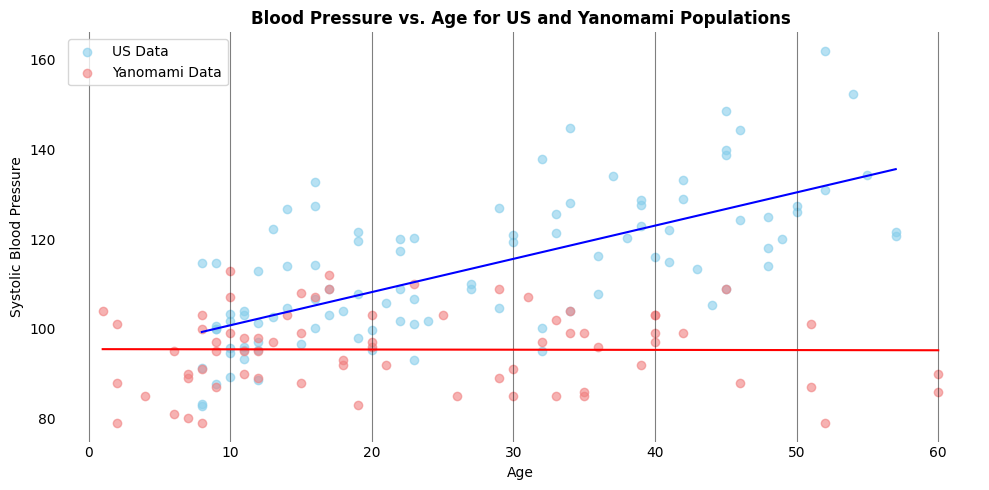

In [50]:
plt.figure(figsize=(10, 5))

plt.scatter(us_x, us_y, label='US Data', alpha=0.6, color='skyblue')
us_liner.plot_model(us_x.min(), us_x.max(), color='blue')

plt.scatter(yan_x, yan_y, label='Yanomami Data', alpha=0.6, color='lightcoral')
yan_liner.plot_model(yan_x.min(), yan_x.max(), color='red')

plt.xlabel('Age')
plt.ylabel('Systolic Blood Pressure')
plt.title('Blood Pressure vs. Age for US and Yanomami Populations', fontweight="bold")

clear_axes()

plt.legend()
plt.tight_layout()
plt.show()

### Conclusion and Confounding Variables

Based on the R-squared values and the plots:

*   **US Data:** The US linear model shows a positive correlation between age and blood pressure (Slope:  0.741). The R-squared value of 0.472 indicates that about 47% of the variance in blood pressure can be explained by age, suggesting a moderate fit.

*   **Yanomami Data:** The Yanomami linear model shows a nearly flat line with a very small negative slope (-0.004). The R-squared value of 0.00005 is extremely low, indicating that age explains almost none of the variance in blood pressure in this population. This suggests that blood pressure does not significantly increase with age among the Yanomami.

#### Confounding Factors

While the data strongly suggests a difference in blood pressure trends with age between the two populations, it does not definitively prove that salt intake *causes* this difference. Other confounding factors that could influence blood pressure and differ between these populations include:

1.  **Diet:** Beyond salt, overall dietary patterns (e.g., processed foods, saturated fats, fiber intake) can significantly impact blood pressure.
2.  **Physical Activity:** Lifestyle differences in physical activity levels can affect cardiovascular health.
3.  **Stress Levels:** Chronic stress can contribute to higher blood pressure.
4.  **Genetics:** Genetic predispositions to hypertension can vary between populations.
5.  **Environmental Factors:** Exposure to pollution, infections, or other environmental stressors.
6.  **Healthcare Access/Medical Conditions:** Differences in underlying medical conditions or access to healthcare could play a role, though this is less likely to be a primary driver for the Yanomami.
